# Lab Exercise 3: Simple Linear Regression
**Student Survey: Scikit-learn, OLS, and Parameter Saving**

**Aim:** Collect real-world student survey data, preprocess it with imputation, perform Simple Linear Regression using Scikit-learn and manually using OLS formulas, compare both, and save model parameters.

**Dataset:** Department Awareness Survey (Responses).csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## Part A: Data Collection and Preprocessing

In [2]:
df = pd.read_csv('Department Awareness Survey (Responses).csv')
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6-22-2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6-22-2026 8:49:51,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6-22-2026 8:50:45,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6-22-2026 8:51:01,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6-22-2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [3]:
print('Shape:', df.shape)

Shape: (54, 15)


In [4]:
df.rename(columns={
    'Registration Number ': 'Reg_No',
    'Job role that you are interested in\n': 'Job_Interest',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'Min_Salary',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'Max_Salary',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)': 'Median_Salary',
    'Which is the highest paying company': 'Top_Company',
    'Rate your contribution towards extra curricular activities': 'Extra_Curricular',
    'Rate your technical competencies': 'Tech_Rating',
    'What are your package expectations (LPA)': 'Pkg_Expect',
    'your CIA % of last semester ': 'CIA',
    'your GPA of last semester': 'GPA',
    'Your maximum attendance % till last semester': 'Attendance',
    'Internships Interests': 'Internship'
}, inplace=True)
print('Columns:', df.columns.tolist())

Columns: ['Timestamp', 'Reg_No', 'Email', 'Job_Interest', 'Min_Salary', 'Max_Salary', 'Median_Salary', 'Top_Company', 'Extra_Curricular', 'Tech_Rating', 'Pkg_Expect', 'CIA', 'GPA', 'Attendance', 'Internship']


### Missing Value Analysis - Before Cleaning

In [5]:
missing_before = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_before.to_string())

                  Missing Count  Missing %
Timestamp                     0        0.0
Reg_No                        0        0.0
Email                         0        0.0
Job_Interest                  0        0.0
Min_Salary                    0        0.0
Max_Salary                    0        0.0
Median_Salary                 0        0.0
Top_Company                   0        0.0
Extra_Curricular              0        0.0
Tech_Rating                   0        0.0
Pkg_Expect                    0        0.0
CIA                           0        0.0
GPA                           0        0.0
Attendance                    0        0.0
Internship                    0        0.0


In [6]:
# Visual: missing % per column (before cleaning)
missing_nonzero = missing_before[missing_before['Missing Count'] > 0]
if len(missing_nonzero) == 0:
    print('No missing values detected in raw data (some are encoded as strings like Option 1, na etc.)')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(missing_nonzero.index, missing_nonzero['Missing %'], color='steelblue')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values Before Cleaning')
    plt.tight_layout()
    plt.show()

No missing values detected in raw data (some are encoded as strings like Option 1, na etc.)


### Data Cleaning - All Columns

In [7]:
# CIA %: strip %, convert to numeric, flag values below 10 as invalid
# (entries like 3.45 and 4 are GPA values entered by mistake)
df['CIA'] = pd.to_numeric(df['CIA'].astype(str).str.replace('%', '').str.strip(), errors='coerce')
df.loc[(df['CIA'] < 10) | (df['CIA'] > 100), 'CIA'] = np.nan

# GPA: convert to numeric, 0-4 scale; values like 10, 90, 7.8 are invalid
df['GPA'] = pd.to_numeric(df['GPA'].astype(str).str.strip(), errors='coerce')
df.loc[(df['GPA'] < 0) | (df['GPA'] > 4), 'GPA'] = np.nan

# Attendance: strip %, 'Option 1' and other strings become NaN via coerce
df['Attendance'] = pd.to_numeric(df['Attendance'].astype(str).str.replace('%', '').str.strip(), errors='coerce')
df.loc[(df['Attendance'] < 0) | (df['Attendance'] > 100), 'Attendance'] = np.nan

# Rating columns (simple 1-5 scale, no units)
for col in ['Extra_Curricular', 'Tech_Rating']:
    df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

print('CIA, GPA, Attendance, Ratings cleaned.')

CIA, GPA, Attendance, Ratings cleaned.


#### Salary and Package Cleaning

Respondents entered salary values in many formats:
- Plain LPA numbers: `4`, `12`, `6.5`
- With suffix: `12LPA`, `6lpa`, `4 LPA`, `10lpa`
- Indian rupee format: `7,00,000`, `5,00,000.00`, `3,00,000`
- Raw rupee amounts: `300000`, `1500000`, `700000`
- Ranges: `7-9`, `8 to 12 lpa`, `5 to 9 LPA`
- Crore: `2cr`
- Trailing operators: `8+`
- Typos: `7,.5`

The `to_lpa()` function below normalises all of these to a single LPA float.

In [8]:
def to_lpa(val):
    s = str(val).strip().lower()
    if s in ['', 'nan', 'option 1', 'none']:
        return np.nan

    # crore notation: '2cr' -> 200 LPA
    cr = re.search(r'([\d.]+)\s*cr', s)
    if cr:
        return float(cr.group(1)) * 100

    # strip 'lpa' suffix
    s = s.replace('lpa', '').strip()

    # range: '7-9' or '8 to 12' -> take average
    rng = re.search(r'([\d.]+)\s*(?:to|-)\s*([\d.]+)', s)
    if rng:
        avg = (float(rng.group(1)) + float(rng.group(2))) / 2
        return avg / 100000 if avg > 500 else avg

    s = s.replace('+', '').strip()         # '8+' -> '8'
    s = re.sub(r',\.', '.', s)             # '7,.5' -> '7.5'
    s = s.replace(',', '').strip()          # '7,00,000' -> '700000'

    try:
        num = float(s)
    except ValueError:
        return np.nan

    # if > 500 it's in rupees (e.g. 700000 -> 7 LPA)
    return num / 100000 if num > 500 else num

salary_cols = ['Min_Salary', 'Max_Salary', 'Median_Salary', 'Pkg_Expect']
for col in salary_cols:
    df[col] = df[col].apply(to_lpa)
    # campus salary range: < 1.5 or > 150 LPA treated as invalid
    df.loc[(df[col] < 1.5) | (df[col] > 150), col] = np.nan

print('Salary columns converted to LPA:')
print(df[salary_cols].describe().round(2))

Salary columns converted to LPA:
       Min_Salary  Max_Salary  Median_Salary  Pkg_Expect
count       53.00       44.00          54.00       53.00
mean         5.11       16.16           8.10       10.10
std          2.45       13.70           5.73        7.47
min          2.00        8.00           4.50        5.00
25%          4.00       12.00           6.00        7.00
50%          4.50       12.00           7.00        8.00
75%          6.00       14.25           8.00       10.00
max         15.00      100.00          45.00       60.00


#### Outlier Detection and Treatment (Salary Columns)

**Method: IQR (Interquartile Range)**

Any value below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is flagged as an outlier and set to NaN. It will then be replaced by the median during imputation.

Note: CIA, GPA, and Attendance are already bounded by domain-known valid ranges (0-100, 0-4, 0-100), so statistical outlier removal is not applied to them.

In [9]:
def flag_iqr_outliers(series, label):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    mask = (series < lo) | (series > hi)
    n_out = mask.sum()
    print(f'{label:<20} Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  fence=[{lo:.1f}, {hi:.1f}]  outliers={n_out}')
    return mask

print(f'{"Column":<20} {"Summary"}')
print('-' * 70)
for col in salary_cols:
    mask = flag_iqr_outliers(df[col], col)
    df.loc[mask, col] = np.nan

Column               Summary
----------------------------------------------------------------------
Min_Salary           Q1=4.0  Q3=6.0  IQR=2.0  fence=[1.0, 9.0]  outliers=4
Max_Salary           Q1=12.0  Q3=14.2  IQR=2.2  fence=[8.6, 17.6]  outliers=10
Median_Salary        Q1=6.0  Q3=8.0  IQR=2.0  fence=[3.0, 11.0]  outliers=4
Pkg_Expect           Q1=7.0  Q3=10.0  IQR=3.0  fence=[2.5, 14.5]  outliers=4


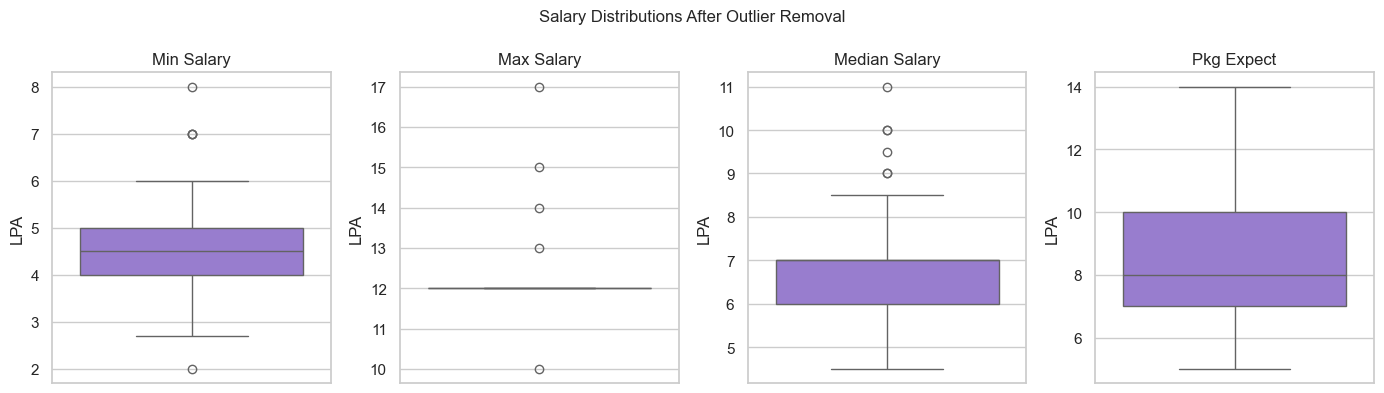

In [10]:
# Box plots showing salary distributions after outlier removal
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, salary_cols):
    sns.boxplot(y=df[col], ax=ax, color='mediumpurple')
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel('LPA')
plt.suptitle('Salary Distributions After Outlier Removal', fontsize=12)
plt.tight_layout()
plt.show()

### Missing Value Analysis - After Conversion (Before Imputation)

In [11]:
numeric_cols = ['CIA', 'GPA', 'Attendance', 'Min_Salary', 'Max_Salary', 'Median_Salary', 'Extra_Curricular', 'Tech_Rating', 'Pkg_Expect']

missing_after_conv = pd.DataFrame({
    'Missing Count': df[numeric_cols].isnull().sum(),
    'Missing %': (df[numeric_cols].isnull().sum() / len(df) * 100).round(2)
})
print(missing_after_conv.to_string())

                  Missing Count  Missing %
CIA                           3       5.56
GPA                           4       7.41
Attendance                    6      11.11
Min_Salary                    5       9.26
Max_Salary                   20      37.04
Median_Salary                 4       7.41
Extra_Curricular              0       0.00
Tech_Rating                   0       0.00
Pkg_Expect                    5       9.26


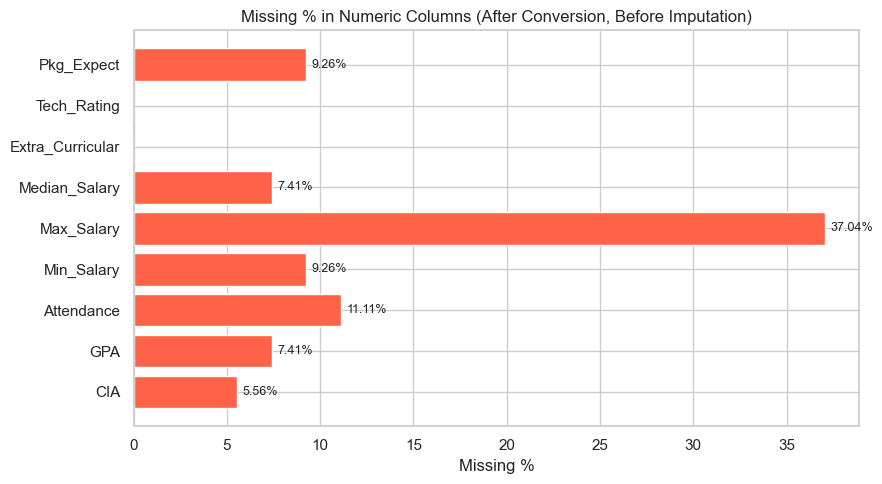

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v > 0 else 'lightgray' for v in missing_after_conv['Missing %']]
ax.barh(missing_after_conv.index, missing_after_conv['Missing %'], color=colors)
ax.set_xlabel('Missing %')
ax.set_title('Missing % in Numeric Columns (After Conversion, Before Imputation)')
for i, v in enumerate(missing_after_conv['Missing %']):
    if v > 0:
        ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Imputation

**Method: Median Imputation** applied to all numeric columns.

**Why median and not mean:**
- The dataset has outliers and wrongly entered values (GPA=90, CIA=3.45, Attendance='Option 1').
- Mean is pulled by these extremes; median stays at the center of the true distribution.
- For ordinal rating scales (1-5), median keeps the imputed value in a natural position.

**Columns imputed:** CIA, GPA, Attendance, Min_Salary, Max_Salary, Median_Salary, Extra_Curricular, Tech_Rating, Pkg_Expect

**Not imputed:** Reg_No, Timestamp, Email, Job_Interest, Top_Company, Internship (categorical or identifier columns not used in regression).

In [13]:
impute_cols = ['CIA', 'GPA', 'Attendance', 'Min_Salary', 'Max_Salary',
               'Median_Salary', 'Extra_Curricular', 'Tech_Rating', 'Pkg_Expect']

print(f'{"Column":<22} {"Missing Before":>15} {"Median Used":>12}')
print('-' * 52)
for col in impute_cols:
    n_miss = df[col].isnull().sum()
    med = df[col].median()
    df[col].fillna(med, inplace=True)
    print(f'{col:<22} {n_miss:>15}  {med:>11.4f}')

Column                  Missing Before  Median Used
----------------------------------------------------
CIA                                  3      71.1100
GPA                                  4       3.5000
Attendance                           6      93.5000
Min_Salary                           5       4.5000
Max_Salary                          20      12.0000
Median_Salary                        4       7.0000
Extra_Curricular                     0       4.0000
Tech_Rating                          0       3.0000
Pkg_Expect                           5       8.0000


In [14]:
print('Missing values after imputation:')
print(df[impute_cols].isnull().sum())

Missing values after imputation:
CIA                 0
GPA                 0
Attendance          0
Min_Salary          0
Max_Salary          0
Median_Salary       0
Extra_Curricular    0
Tech_Rating         0
Pkg_Expect          0
dtype: int64


In [15]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}. Remaining rows: {len(df)}')

Duplicates removed: 0. Remaining rows: 54


In [16]:
df[['CIA', 'GPA', 'Attendance']].describe()

,CIA,GPA,Attendance
count,54.00000,54.000000,54.000000
mean,73.88963,3.478519,93.163519
std,6.42520,0.258825,4.528431
min,60.00000,2.900000,85.000000
25%,70.00000,3.377500,90.000000
50%,71.11000,3.500000,93.500000
75%,78.99750,3.600000,97.000000
max,89.00000,4.000000,100.000000


### Data Distributions - Before Regression

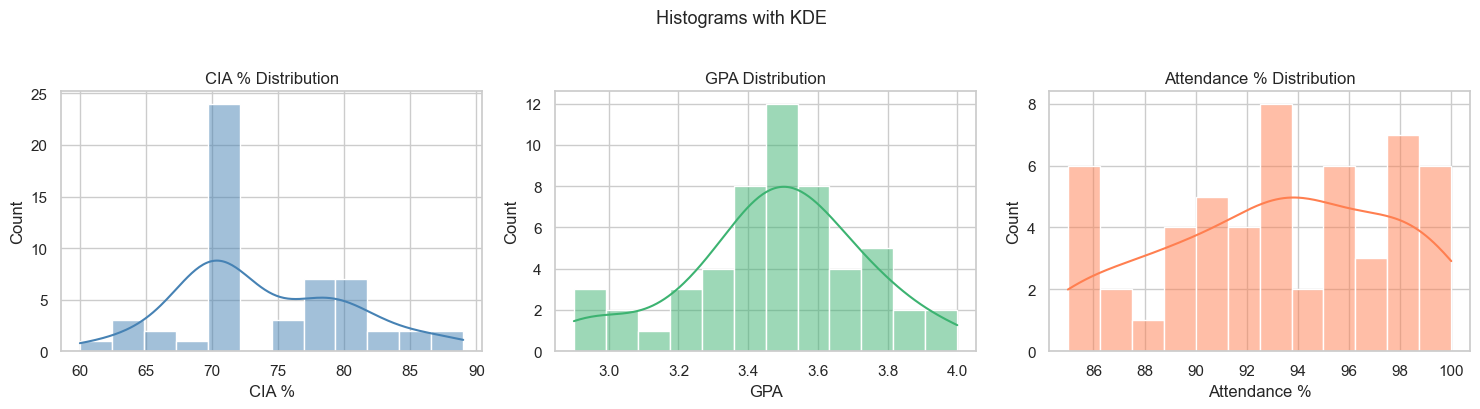

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['CIA'], kde=True, ax=axes[0], color='steelblue', bins=12)
axes[0].set_title('CIA % Distribution')
axes[0].set_xlabel('CIA %')

sns.histplot(df['GPA'], kde=True, ax=axes[1], color='mediumseagreen', bins=12)
axes[1].set_title('GPA Distribution')
axes[1].set_xlabel('GPA')

sns.histplot(df['Attendance'], kde=True, ax=axes[2], color='coral', bins=12)
axes[2].set_title('Attendance % Distribution')
axes[2].set_xlabel('Attendance %')

plt.suptitle('Histograms with KDE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

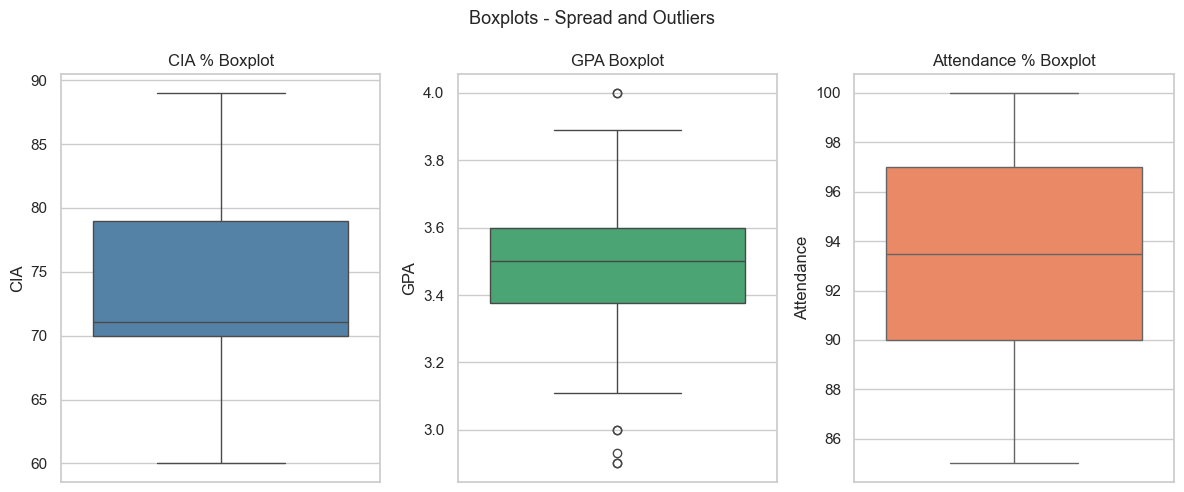

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.boxplot(y=df['CIA'], ax=axes[0], color='steelblue')
axes[0].set_title('CIA % Boxplot')

sns.boxplot(y=df['GPA'], ax=axes[1], color='mediumseagreen')
axes[1].set_title('GPA Boxplot')

sns.boxplot(y=df['Attendance'], ax=axes[2], color='coral')
axes[2].set_title('Attendance % Boxplot')

plt.suptitle('Boxplots - Spread and Outliers', fontsize=13)
plt.tight_layout()
plt.show()

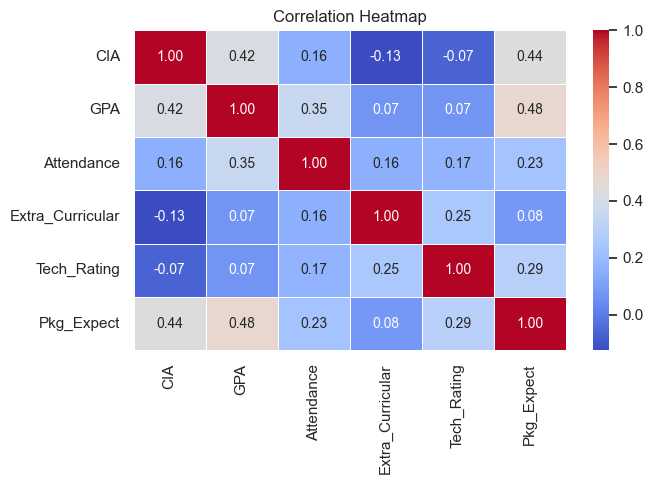

In [19]:
corr = df[['CIA', 'GPA', 'Attendance', 'Extra_Curricular', 'Tech_Rating', 'Pkg_Expect']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Experiment Setup

**Experiment 1:** Independent Variable (X) = CIA %,  Dependent Variable (Y) = GPA

**Experiment 2:** Independent Variable (X) = Attendance %,  Dependent Variable (Y) = GPA

In [20]:
X1 = df[['CIA']]
y1 = df['GPA']

X2 = df[['Attendance']]
y2 = df['GPA']

print('Experiment 1 - X:', X1.shape, ' y:', y1.shape)
print('Experiment 2 - X:', X2.shape, ' y:', y2.shape)

Experiment 1 - X: (54, 1)  y: (54,)
Experiment 2 - X: (54, 1)  y: (54,)


## Part B: Simple Linear Regression using Scikit-learn

### Experiment 1: CIA % -> GPA

In [21]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)

print('Slope (m)    :', model1.coef_[0])
print('Intercept (b):', model1.intercept_)

r2_train1 = model1.score(X1_train, y1_train)
r2_test1  = model1.score(X1_test,  y1_test)
print(f'R2 (train)   : {r2_train1:.4f}')
print(f'R2 (test)    : {r2_test1:.4f}')

y1_pred_sklearn = model1.predict(X1_test)

result1 = pd.DataFrame({
    'Actual'   : y1_test.values,
    'Predicted': np.round(y1_pred_sklearn, 4)
}).reset_index(drop=True)
print(result1)

Slope (m)    : 0.0156745648995097
Intercept (b): 2.3342528819441632
R2 (train)   : 0.1623
R2 (test)    : 0.1339
    Actual  Predicted
0     3.75     3.5569
1     3.74     3.5569
2     3.46     3.4550
3     3.48     3.4315
4     3.00     3.5098
5     3.50     3.4315
6     2.90     3.3688
7     3.50     3.6823
8     3.20     3.4315
9     3.60     3.5098
10    3.40     3.3479


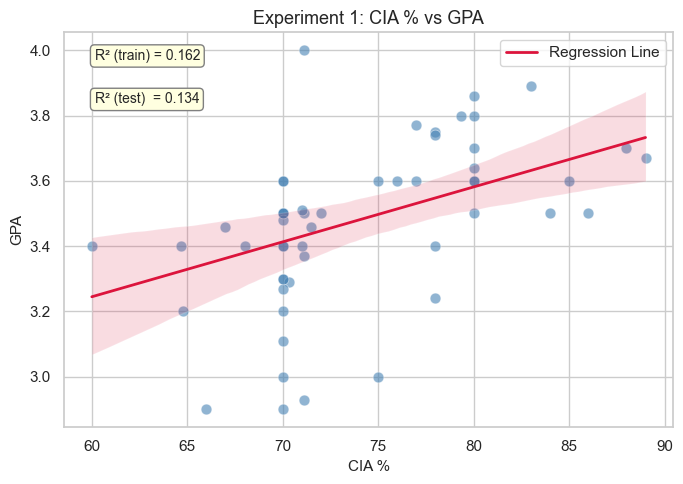

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    x='CIA', y='GPA', data=df, ax=ax,
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 's': 60, 'edgecolors': 'white', 'linewidths': 0.5},
    line_kws={'color': 'crimson', 'lw': 2, 'label': 'Regression Line'},
    ci=95
)
ax.set_title('Experiment 1: CIA % vs GPA', fontsize=13)
ax.set_xlabel('CIA %', fontsize=11)
ax.set_ylabel('GPA', fontsize=11)
ax.text(0.05, 0.93, f'R\u00b2 (train) = {r2_train1:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.text(0.05, 0.82, f'R\u00b2 (test)  = {r2_test1:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.legend()
plt.tight_layout()
plt.show()

### Experiment 2: Attendance % -> GPA

In [23]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print('Slope (m)    :', model2.coef_[0])
print('Intercept (b):', model2.intercept_)

r2_train2 = model2.score(X2_train, y2_train)
r2_test2  = model2.score(X2_test,  y2_test)
print(f'R2 (train)   : {r2_train2:.4f}')
print(f'R2 (test)    : {r2_test2:.4f}')

y2_pred_sklearn = model2.predict(X2_test)

result2 = pd.DataFrame({
    'Actual'   : y2_test.values,
    'Predicted': np.round(y2_pred_sklearn, 4)
}).reset_index(drop=True)
print(result2)

Slope (m)    : 0.01881791974364075
Intercept (b): 1.74223704014653
R2 (train)   : 0.1164
R2 (test)    : 0.0487
    Actual  Predicted
0     3.75     3.5299
1     3.74     3.6116
2     3.46     3.5864
3     3.48     3.5676
4     3.00     3.4358
5     3.50     3.3794
6     2.90     3.4547
7     3.50     3.3606
8     3.20     3.4735
9     3.60     3.5111
10    3.40     3.5299


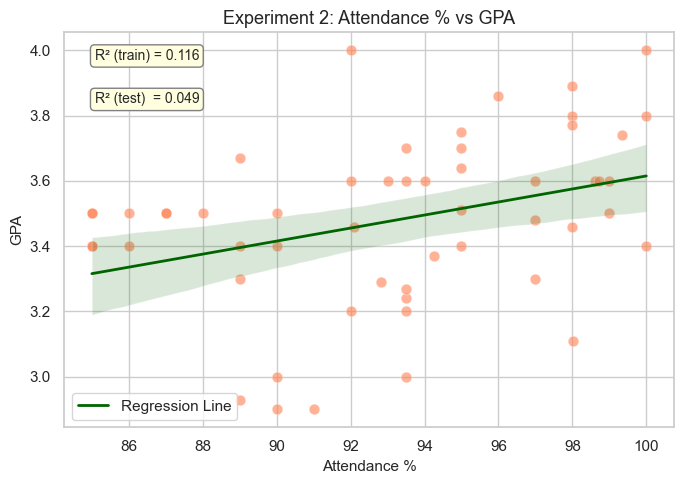

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    x='Attendance', y='GPA', data=df, ax=ax,
    scatter_kws={'alpha': 0.6, 'color': 'coral', 's': 60, 'edgecolors': 'white', 'linewidths': 0.5},
    line_kws={'color': 'darkgreen', 'lw': 2, 'label': 'Regression Line'},
    ci=95
)
ax.set_title('Experiment 2: Attendance % vs GPA', fontsize=13)
ax.set_xlabel('Attendance %', fontsize=11)
ax.set_ylabel('GPA', fontsize=11)
ax.text(0.05, 0.93, f'R\u00b2 (train) = {r2_train2:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.text(0.05, 0.82, f'R\u00b2 (test)  = {r2_test2:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.legend()
plt.tight_layout()
plt.show()

## Part C: Manual Computation using Ordinary Least Squares (OLS)

$$m = \frac{n\sum xy - \sum x \sum y}{n\sum x^2 - (\sum x)^2}$$

$$b = \frac{\sum y - m\sum x}{n}$$

In [25]:
def ols_regression(x, y):
    n      = len(x)
    sum_x  = np.sum(x)
    sum_y  = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y - m * sum_x) / n
    return m, b

### Experiment 1 OLS

In [26]:
m1_ols, b1_ols = ols_regression(X1_train['CIA'].values, y1_train.values)
print('OLS Slope (m)    :', m1_ols)
print('OLS Intercept (b):', b1_ols)
print(f'Equation: GPA = {m1_ols:.4f} * CIA + {b1_ols:.4f}')
y1_pred_ols = m1_ols * X1_test['CIA'].values + b1_ols

OLS Slope (m)    : 0.015674564899509698
OLS Intercept (b): 2.3342528819441637
Equation: GPA = 0.0157 * CIA + 2.3343


### Experiment 2 OLS

In [27]:
m2_ols, b2_ols = ols_regression(X2_train['Attendance'].values, y2_train.values)
print('OLS Slope (m)    :', m2_ols)
print('OLS Intercept (b):', b2_ols)
print(f'Equation: GPA = {m2_ols:.4f} * Attendance + {b2_ols:.4f}')
y2_pred_ols = m2_ols * X2_test['Attendance'].values + b2_ols

OLS Slope (m)    : 0.018817919743643906
OLS Intercept (b): 1.7422370401462357
Equation: GPA = 0.0188 * Attendance + 1.7422


## Comparison: Scikit-learn vs OLS

### Experiment 1

In [28]:
comp1 = pd.DataFrame({
    'Actual'      : y1_test.values,
    'Sklearn_Pred': np.round(y1_pred_sklearn, 4),
    'OLS_Pred'    : np.round(y1_pred_ols, 4),
    'Difference'  : np.round(np.abs(y1_pred_sklearn - y1_pred_ols), 8)
})
print(comp1.reset_index(drop=True).to_string())
print(f'\nSklearn  slope={model1.coef_[0]:.6f}  intercept={model1.intercept_:.6f}')
print(f'OLS      slope={m1_ols:.6f}  intercept={b1_ols:.6f}')

    Actual  Sklearn_Pred  OLS_Pred  Difference
0     3.75        3.5569    3.5569         0.0
1     3.74        3.5569    3.5569         0.0
2     3.46        3.4550    3.4550         0.0
3     3.48        3.4315    3.4315         0.0
4     3.00        3.5098    3.5098         0.0
5     3.50        3.4315    3.4315         0.0
6     2.90        3.3688    3.3688         0.0
7     3.50        3.6823    3.6823         0.0
8     3.20        3.4315    3.4315         0.0
9     3.60        3.5098    3.5098         0.0
10    3.40        3.3479    3.3479         0.0

Sklearn  slope=0.015675  intercept=2.334253
OLS      slope=0.015675  intercept=2.334253


### Experiment 2

In [29]:
comp2 = pd.DataFrame({
    'Actual'      : y2_test.values,
    'Sklearn_Pred': np.round(y2_pred_sklearn, 4),
    'OLS_Pred'    : np.round(y2_pred_ols, 4),
    'Difference'  : np.round(np.abs(y2_pred_sklearn - y2_pred_ols), 8)
})
print(comp2.reset_index(drop=True).to_string())
print(f'\nSklearn  slope={model2.coef_[0]:.6f}  intercept={model2.intercept_:.6f}')
print(f'OLS      slope={m2_ols:.6f}  intercept={b2_ols:.6f}')

    Actual  Sklearn_Pred  OLS_Pred  Difference
0     3.75        3.5299    3.5299         0.0
1     3.74        3.6116    3.6116         0.0
2     3.46        3.5864    3.5864         0.0
3     3.48        3.5676    3.5676         0.0
4     3.00        3.4358    3.4358         0.0
5     3.50        3.3794    3.3794         0.0
6     2.90        3.4547    3.4547         0.0
7     3.50        3.3606    3.3606         0.0
8     3.20        3.4735    3.4735         0.0
9     3.60        3.5111    3.5111         0.0
10    3.40        3.5299    3.5299         0.0

Sklearn  slope=0.018818  intercept=1.742237
OLS      slope=0.018818  intercept=1.742237


**Observation:** Both Scikit-learn and manual OLS produce the same slope and intercept. The prediction difference is zero except for floating-point noise, confirming that Scikit-learn's LinearRegression internally minimizes the same OLS cost function.

## Parameter Saving using Pickle

In [30]:
params = {
    'exp1_cia_gpa': {
        'slope'    : model1.coef_[0],
        'intercept': model1.intercept_
    },
    'exp2_attendance_gpa': {
        'slope'    : model2.coef_[0],
        'intercept': model2.intercept_
    }
}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(params, f)

print('Saved to linear_regression_weights.pkl')

Saved to linear_regression_weights.pkl


In [31]:
with open('linear_regression_weights.pkl', 'rb') as f:
    loaded = pickle.load(f)

print('Loaded parameters:')
for exp, v in loaded.items():
    print(f"  {exp}: slope={v['slope']:.6f}, intercept={v['intercept']:.6f}")

Loaded parameters:
  exp1_cia_gpa: slope=0.015675, intercept=2.334253
  exp2_attendance_gpa: slope=0.018818, intercept=1.742237


In [32]:
m1_l = loaded['exp1_cia_gpa']['slope']
b1_l = loaded['exp1_cia_gpa']['intercept']
cia_in = 75
print(f'Predicted GPA for CIA={cia_in}%  ->  {m1_l * cia_in + b1_l:.4f}')

m2_l = loaded['exp2_attendance_gpa']['slope']
b2_l = loaded['exp2_attendance_gpa']['intercept']
att_in = 90
print(f'Predicted GPA for Attendance={att_in}%  ->  {m2_l * att_in + b2_l:.4f}')

Predicted GPA for CIA=75%  ->  3.5098
Predicted GPA for Attendance=90%  ->  3.4358


## Final Observations

1. Raw data had multiple issues across all columns. CIA and Attendance had % symbols; GPA had values outside 0-4 (e.g. 10, 90, 7.8); CIA had GPA values entered by mistake (3.45, 4); Attendance had 'Option 1' from respondents who left the dropdown unchanged. Salary columns had the most variety: plain LPA numbers, LPA-suffixed strings, Indian rupee comma format (7,00,000), raw rupee amounts (700000), ranges (7-9 or 8 to 12 lpa), crore notation (2cr), and typos (7,.5). The to_lpa() function normalises all of these to a single LPA float.

2. Median imputation was used for all numeric columns. Median is preferred because the dataset has outliers and incorrectly entered values that would shift a mean-based imputation away from the true center.

3. Both Scikit-learn and manual OLS give the same slope and intercept. The Difference column in the comparison is effectively zero, confirming that Scikit-learn's LinearRegression solves OLS internally.

4. CIA % shows a mild positive correlation with GPA. Students with higher CIA scores tend to have slightly better GPAs.

5. Attendance % also shows a positive but weaker trend with GPA. The relationship is less pronounced, partly because Attendance values were tightly clustered in the upper range after imputation.

6. Pickle lets us store the learned slope and intercept and reuse them for prediction without retraining.